(512, 512)


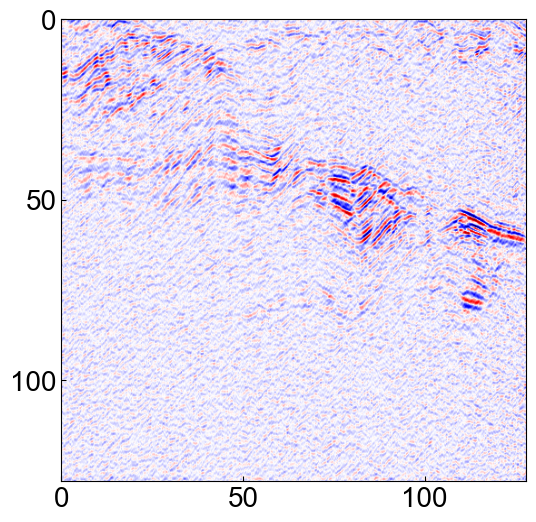

In [ ]:
#可视化
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_data(data):
        min_val = data.min()
        max_val = data.max()
        return (data - min_val) / (max_val - min_val)
      
    data = np.load(r"D:\桌面\项目\U_Net3+ 合成记录测试\开源数据集训练CODE\数据集(整个剖面)\noisy_npy\noisy_0000.npy")
    # np.save(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_U-Net3+_noise(k=3).npy", data)
    print(data.shape)
    # data = data[80:360, 312:512]
    # data = np.load(r"D:\桌面\项目\Stratton\data\Stratton3D_32bit.npy")
    # # data = data[50, 6:230, 126:1486]  
    # # data = data[50, 6:230, 1126:1494] 
    # data = data[200, 72:200, 1050:1418] #论文里的
    # # data = data[200, 6:] #论文里的
    # print(data.shape)
    # # data = data[150, 50:178, 750:1118] 
    # data = data.T
    data = normalize_data(data) 

    colors = [
        (0.0, '#7fff7f'),  # 亮绿色
        (0.2, '#b3ff66'),  # 浅绿色
        (0.4, '#ffff00'),  # 黄色
        (0.6, '#ff9900'),  # 橙色
        (0.8, '#ff4d00'),  # 红橙色
        (1.0, '#990000')   # 深红色
    ]
    cust_cmap = LinearSegmentedColormap.from_list('seismic_green', colors)

    height, width = data.shape
    aspect_ratio = width / height
    fig_width = 6  # 自定义宽度（英寸）
    fig_height = fig_width / aspect_ratio  # 根据比例计算高度
    figsize=(fig_width, fig_height)

    plt.figure(figsize=figsize)  #figsize=figsize
    # plt.title('MSSA去噪结果')
    plt.imshow(data, aspect='auto', cmap="seismic", extent = [0, 128, 128, 0])  #MAMI [2000, 2512, 2848, 800]      Stratton[72, 200, 2836, 2100]      
    plt.clim(0, 1)
    plt.tick_params(direction='in')
    # plt.colorbar()
    # plt.ylabel('Time(ms)', fontsize=24, family='Arial')
    # plt.xlabel('Trace',  fontsize=24, family='Arial')
    plt.xticks(fontsize=20, fontname='Arial')
    plt.yticks(fontsize=20, fontname='Arial')

    plt.locator_params(axis='x', nbins=4)  # 横轴大约6个刻度
    plt.locator_params(axis='y', nbins=4)  # 纵轴大约8个刻度

    # plt.savefig(r'D:\桌面\项目\Stratton\图件汇总（刻度线朝内）\MAMI\Sample_1', dpi=600, bbox_inches='tight')
    plt.show()  

(512, 512)


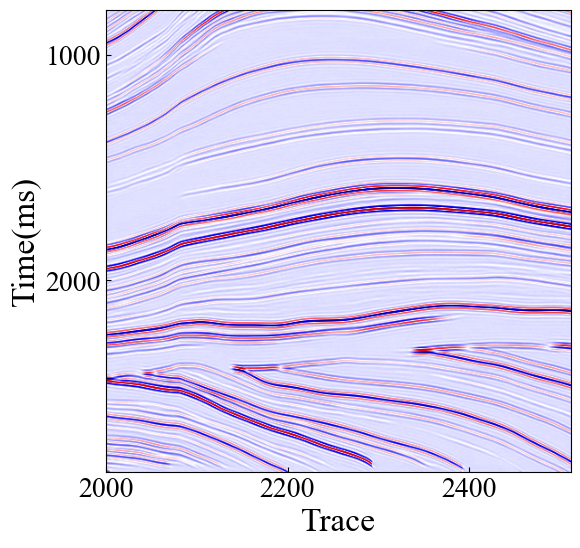

In [2]:
# 矢量图
# 可视化
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    import os
    from matplotlib import rcParams

    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_data(data):
        min_val = data.min()
        max_val = data.max()
        return (data - min_val) / (max_val - min_val)
    
    def normalize_to_neg1_1(data):
        """
        将已归一化到 [0, 1] 的地震剖面数据进一步归一化到 [-1, 1]

        参数:
            data (np.ndarray): 已经归一化到 [0, 1] 的地震数据数组

        返回:
            np.ndarray: 归一化到 [-1, 1] 的数据
        """
        if not isinstance(data, np.ndarray):
            data = np.array(data, dtype=np.float32)

        # 检查数据范围是否在 [0, 1]
        if np.min(data) < 0 or np.max(data) > 1:
            print("⚠️ 警告：输入数据不在 [0, 1] 区间内，可能导致结果异常。")
        return 2 * data - 1
    # data = np.load(r"D:\桌面\项目\U_Net3+ 合成记录测试\开源数据集训练CODE\数据集(整个剖面)\noisy_npy\noisy_0000.npy")
    # data_path = r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\Black_UNet3+_SSIM.npy"
    data_path = r"D:\桌面\随机噪声压制\Marmousi\data\MAMI_U-Net_denoised(k=1).npy"
    data = np.load(data_path)

    # data = data[150:800, :] # MAMI 地震剖面
    # data = data[200, 72:200, 1050:1418] # Stratton 切片
    # data = data[200, 6:] # Stratton 地震剖面
    # data = data.T
    # data = data[80:360, 312:512]  # Black Bridge 切片
    print(data.shape)
    # data = normalize_data(data)

    colors = [
        (0.0, '#7fff7f'),
        (0.2, '#b3ff66'),
        (0.4, '#ffff00'),
        (0.6, '#ff9900'),
        (0.8, '#ff4d00'),
        (1.0, '#990000')
    ]

    cust_cmap = LinearSegmentedColormap.from_list('seismic_green', colors)
    height, width = data.shape
    aspect_ratio = width / height
    fig_width = 6  
    fig_height = fig_width / aspect_ratio
    figsize = (fig_width, fig_height)

    plt.figure(figsize=figsize) #     figsize=figsize        cust_cmap    "seismic"
    plt.imshow(data, aspect='auto', cmap="seismic", extent=[2000, 2512, 2848, 800])#  MAMI [2000, 2512, 2848, 800]      Stratton[72, 200, 2836, 2100]
    plt.clim(0, 1)                                                                #  Black [500, 1012, 1824, 800]   [800, 1012, 1520, 960]
    plt.tick_params(direction='in')
    plt.ylabel('Time(ms)', fontsize=24, family='Times New Roman')
    plt.xlabel('Trace',  fontsize=24, family='Times New Roman')
    plt.xticks(fontsize=20, fontname='Times New Roman')
    plt.yticks(fontsize=20, fontname='Times New Roman')
    plt.locator_params(axis='x', nbins=4)
    plt.locator_params(axis='y', nbins=4)

    file_name = os.path.splitext(os.path.basename(data_path))[0]
    save_base = fr'D:\桌面\随机噪声压制\Stratton\矢量图(Times New Roman)\MAMI\{file_name}'
    # save_base = fr'D:\桌面\项目\Stratton\矢量图(Times New Roman)(2)\Black\{file_name}'
    plt.savefig(f'{save_base}.eps', format='eps', dpi=600, bbox_inches='tight')
    plt.savefig(f'{save_base}.png', format='png', dpi=600, bbox_inches='tight')
    plt.savefig(f'{save_base}.pdf', format='pdf', dpi=600, bbox_inches='tight')
    plt.show()


In [ ]:
#定量分析
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    from matplotlib import rcParams
    import segyio
    from skimage.metrics import structural_similarity as ssim
    from matplotlib.colors import LinearSegmentedColormap
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    # 计算信噪比（SNR）
    def calculate_snr(predictions, targets):
        noise = predictions - targets
        signal_power = np.mean(targets**2)
        noise_power = np.mean(noise**2)
        return 10 * np.log10(signal_power / noise_power)

    def mse(x, y):
        return np.mean((x - y) ** 2)

    def psnr(x, y, max_value=1.0):
        """计算峰值信噪比（PSNR）"""
        mse_value = mse(x, y)
        if mse_value == 0:
            return float('inf')  # 完全相同的数据，PSNR 为无穷大
        return 10 * np.log10((max_value ** 2) / mse_value)

    # 加载数据
    # i = 3
    # if i == 1:
    #     result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")
    #     pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_CONVENTIONAL_NOISE.npy")
    # elif i == 2:
    #     result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")
    #     pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_UNet_noise(k=3).npy")  
    # else :
    #     result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")
    #     pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_U-Net3+_noise(k=3).npy")

    result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_noised(k=3).npy")
    pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")

    data_range = result.max() - result.min()
    Mse = mse(result, pure)
    Ssim, map = ssim(result, pure, full = True, data_range=data_range, win_size=7)
    Snr = calculate_snr(result, pure)
    Psnr = psnr(result, pure)
    print("MSE:", Mse, "\n","SSIM:", Ssim, "\n", "SNR:", Snr, "\n","PSNR:", Psnr)
    # np.save(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_UNet3+_SSIM", map)

    colors = [
        (0.0, '#7fff7f'),  # 亮绿色
        (0.2, '#b3ff66'),  # 浅绿色
        (0.4, '#ffff00'),  # 黄色
        (0.6, '#ff9900'),  # 橙色
        (0.8, '#ff4d00'),  # 红橙色
        (1.0, '#990000')   # 深红色
    ]
    cust_cmap = LinearSegmentedColormap.from_list('seismic_green', colors)
    plt.figure()
    plt.imshow(map, cmap=cust_cmap, aspect='auto')  # viridis  gist_earth_r  terrain_r
    # plt.title('SSIM Map')
    plt.colorbar()
    # plt.clim(0, 0.5)
    # plt.savefig(r'D:\桌面\项目\Stratton\图件汇总\Stratton\STRATTON_UNET3+_SSIM', dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
#SVD去噪
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def svd_denoise(data, rank):
        """
        使用SVD进行矩阵去噪
        参数:
            data: 输入二维矩阵（例如一幅地震剖面）
            rank: 保留的奇异值数量（越大保留越多信息，越小去噪越强）
        返回:
            去噪后的矩阵
        """
        # 1. 奇异值分解
        U, S, VT = np.linalg.svd(data, full_matrices=False)

        # 2. 构造只保留前rank个奇异值的S
        S[rank:] = 0
        S_denoised = np.diag(S)

        # 3. 重构矩阵
        denoised = np.dot(U, np.dot(S_denoised, VT))
        return denoised

    # noisy_data = np.load(r"D:\桌面\项目\Stratton\data\dn50.npy")

    # noisy_data = np.load(r"D:\桌面\项目\Stratton\data\Stratton3D_32bit.npy")
    # noisy_data = noisy_data[200, 72:200, 1050:1418].T 

    noisy_data = np.load(r"D:\桌面\项目\U_Net3+ 合成记录测试\开源数据集训练CODE\data\noised(k=3).npy")

    # 去噪处理
    denoised_data = svd_denoise(noisy_data, rank=35)

    # 绘图对比
    plt.figure()
    plt.imshow(noisy_data, cmap='seismic', aspect="auto")
    plt.title('带噪数据')
    plt.colorbar()

    plt.figure()
    plt.imshow(denoised_data, cmap='seismic', aspect="auto")
    plt.title('SVD去噪后')
    plt.colorbar()

    plt.figure()
    plt.imshow(noisy_data-denoised_data, cmap='seismic', aspect="auto")
    plt.title('去除的噪声')
    plt.colorbar()

d:\Anaconda\envs\python_for_DL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\python_for_DL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20284 (\N{CJK UNIFIED IDEOGRAPH-4F3C}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\python_for_DL\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


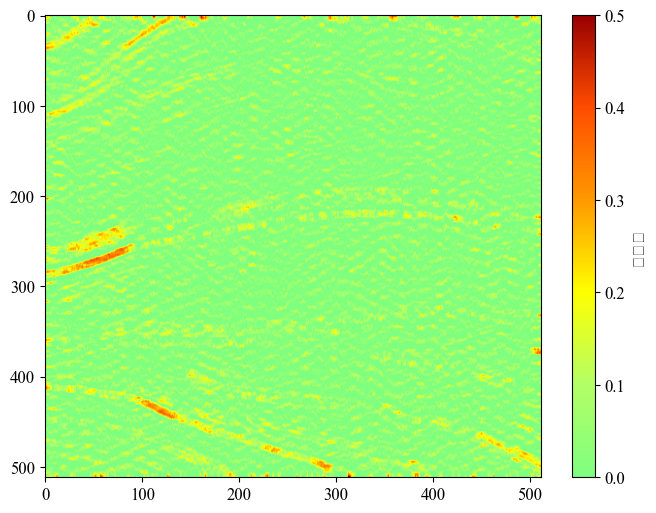

In [18]:
#局部相似性
if __name__ == '__main__':    
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.ndimage import uniform_filter

    def local_similarity(data1, data2, window_size=11):
        assert data1.shape == data2.shape, "输入数据维度不匹配"
        assert window_size % 2 == 1, "窗口大小需为奇数"
        prod = data1 * data2
        sum_prod = uniform_filter(prod, size=window_size, mode='reflect')
        sum11 = uniform_filter(data1**2, size=window_size, mode='reflect')
        sum22 = uniform_filter(data2**2, size=window_size, mode='reflect')
        epsilon = 1e-10
        denominator = np.sqrt(sum11 * sum22) + epsilon
        sim_map = (sum_prod) / denominator
        return sim_map
    i = 1
    # if i == 1:
    #     result = np.load(r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\Black_clean.npy")
    #     pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\BLACK_CONVENTIONAL_NOISE.npy")
    # elif i == 2:
    #     result = np.load(r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\Black_clean.npy")
    #     pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\Black_UNet_noise.npy")  
    # else :
    #     result = np.load(r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\Black_clean.npy")
    #     pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\Black Bridge\Black_UNet3+_noise.npy")

    if i == 1:
        result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")
        pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_CONVENTIONAL_NOISE.npy")
    elif i == 2:
        result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")
        pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_UNet_noise(k=3).npy")  
    else :
        result = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_clean.npy")
        pure = np.load(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_U-Net3+_noise(k=3).npy")

    colors = [
        (0.0, '#7fff7f'),  # 亮绿色
        (0.2, '#b3ff66'),  # 浅绿色
        (0.4, '#ffff00'),  # 黄色
        (0.6, '#ff9900'),  # 橙色
        (0.8, '#ff4d00'),  # 红橙色
        (1.0, '#990000')   # 深红色
    ]
    cust_cmap = LinearSegmentedColormap.from_list('seismic_green', colors)

    sim_cross = local_similarity(result, pure, window_size=9)
    # np.save(r"D:\桌面\项目\Stratton\数据汇总\MAMI\MAMI_Conventional_SSIM", sim_cross)
    plt.figure(figsize=(8, 6))
    plt.imshow(sim_cross, cmap=cust_cmap, aspect='auto')  # viridis 
    plt.colorbar(label='相似性')
    plt.clim(0, 0.5)
    plt.show()

In [ ]:
#传统方法去噪  Stratton
#
if __name__ == '__main__':
    import numpy as np
    from scipy.fft import rfft, irfft
    from scipy.linalg import eigh
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_patch(patch):
        min_val = patch.min()
        max_val = patch.max()
        if max_val - min_val < 1e-6:
            return np.zeros_like(patch)
        return (patch - min_val) / (max_val - min_val)

    def fx_sgd_denoise(data, dx, rank=None):

        # 1. 傅里叶变换到频率域
        freq_data = rfft(data, axis=0)
        nf, nx = freq_data.shape
        denoised_freq = np.zeros_like(freq_data, dtype=complex)
        
        for f_idx in range(nf):
            freq_slice = freq_data[f_idx, :]
            
            # 2. 构建Hankel轨迹矩阵
            L = nx - dx + 1
            H = np.zeros((dx, L), dtype=complex)
            for i in range(dx):
                H[i, :] = freq_slice[i:i+L]
            
            # 3. 计算协方差矩阵 A = H^T H
            A = H.T.conj() @ H  # A维度: L×L
            
            # 4. 构建Hamiltonian矩阵 M = [[A, 0], [0, -A^T]]
            M_upper = np.hstack([A, np.zeros((L, L))])
            M_lower = np.hstack([np.zeros((L, L)), -A.T])
            M = np.vstack([M_upper, M_lower])  # M维度: 2L×2L
            
            # 5. 计算N = M^2
            N = M @ M
            
            # 6. 特征分解
            eigvals, eigvecs = eigh(N)  # eigvecs维度: 2L×2L
            
            # 7. 自适应秩选择
            if rank is None:
                # 简化的自适应秩选择（实际应使用辛几何熵）
                svd_vals = np.sqrt(np.abs(eigvals))
                cumulative = np.cumsum(svd_vals[::-1])
                total = cumulative[-1]
                rank = np.argmax(cumulative > 0.95*total) + 1
            
            Q = eigvecs[:, -rank:]
            
            # 重构公式: \widetilde{H} = H @ (V @ V^H)
            # V是A的特征向量 (来自Q的子矩阵)
            V = Q[:L, :]  # 取前L行 (L×m)
            H_recon = H @ (V @ V.T.conj())  # (dx×L) @ (L×L) = dx×L
            
            # 9. 对角平均还原数据
            denoised_slice = np.zeros(nx, dtype=complex)
            count = np.zeros(nx)
            for i in range(dx):
                for j in range(L):
                    idx = i + j
                    denoised_slice[idx] += H_recon[i, j]
                    count[idx] += 1
            denoised_freq[f_idx, :] = denoised_slice / np.maximum(count, 1)
        
        return irfft(denoised_freq, axis=0, n=data.shape[0])

    # 使用示例
    if __name__ == "__main__":
        # 生成模拟地震数据 (时间×空间)
        noisy_data = np.load(r"D:\桌面\项目\Stratton\data\Stratton3D_32bit.npy")
        data= noisy_data[200, 72:200, 1050:1418].T 
        # data = noisy_data[150, 50:178, 750:1118].T 

        data = normalize_patch(data)

        # data = np.load(r"D:\桌面\项目\U_Net3+ 合成记录测试\开源数据集训练CODE\data\noised(k=3).npy")
        # data = np.load(r"D:\桌面\项目\Stratton\data\CU_717_2_50_denoised.npy")
        # data = np.load(r"D:\桌面\项目\shandong\data\shandongnoised.npy")
        # data = data[0:256, :]
        # 参数设置
        dx = 40 # x方向嵌入维度
        rank = 5 # 固定秩参数
        
        # 执行降噪
        denoised = fx_sgd_denoise(data, dx, rank)
        # np.save(r"D:\桌面\项目\Stratton\方法对比\STRATTON_NOISED.npy",data)
        # np.save(r"D:\桌面\项目\Stratton\方法对比\STRATTON_CONVENTIONAL_DENOISED.npy",denoised)
        # np.save(r"D:\桌面\项目\Stratton\方法对比\STRATTON_CONVENTIONAL_NOISE.npy",data - denoised)

        colors = [(0, 0, 0), (1, 1, 1), (1, 0, 0)]  # 黑 → 白 → 红
        black_white_red = LinearSegmentedColormap.from_list('black_white_red', colors, N=256)

        # # 绘图对比
        plt.figure()
        plt.imshow(data, cmap=black_white_red, aspect='auto', interpolation='nearest')
        # plt.imshow(data, "seismic", aspect='auto')
        plt.title('带噪数据')
        plt.colorbar()

        plt.figure()
        # plt.imshow(denoised, "seismic", aspect='auto')
        plt.imshow(denoised, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.title('SVD去噪后')
        plt.colorbar()

        plt.figure()
        plt.imshow(data-denoised, cmap=black_white_red, aspect='auto', interpolation='nearest')
        # plt.imshow(data-denoised, "seismic", aspect='auto')
        plt.title('去除的噪声')
        plt.clim(-1,1)
        plt.colorbar()
        plt.show()

In [ ]:
#传统方法去噪  MAMI
#
if __name__ == '__main__':
    import numpy as np
    from scipy.fft import rfft, irfft
    from scipy.linalg import eigh
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_patch(patch):
        min_val = patch.min()
        max_val = patch.max()
        if max_val - min_val < 1e-6:
            return np.zeros_like(patch)
        return (patch - min_val) / (max_val - min_val)

    def fx_sgd_denoise(data, dx, rank=None):

        # 1. 傅里叶变换到频率域
        freq_data = rfft(data, axis=0)
        nf, nx = freq_data.shape
        denoised_freq = np.zeros_like(freq_data, dtype=complex)
        
        for f_idx in range(nf):
            freq_slice = freq_data[f_idx, :]
            
            # 2. 构建Hankel轨迹矩阵
            L = nx - dx + 1
            H = np.zeros((dx, L), dtype=complex)
            for i in range(dx):
                H[i, :] = freq_slice[i:i+L]
            
            # 3. 计算协方差矩阵 A = H^T H
            A = H.T.conj() @ H  # A维度: L×L
            
            # 4. 构建Hamiltonian矩阵 M = [[A, 0], [0, -A^T]]
            M_upper = np.hstack([A, np.zeros((L, L))])
            M_lower = np.hstack([np.zeros((L, L)), -A.T])
            M = np.vstack([M_upper, M_lower])  # M维度: 2L×2L
            
            # 5. 计算N = M^2
            N = M @ M
            
            # 6. 特征分解
            eigvals, eigvecs = eigh(N)  # eigvecs维度: 2L×2L
            
            # 7. 自适应秩选择
            if rank is None:
                # 简化的自适应秩选择（实际应使用辛几何熵）
                svd_vals = np.sqrt(np.abs(eigvals))
                cumulative = np.cumsum(svd_vals[::-1])
                total = cumulative[-1]
                rank = np.argmax(cumulative > 0.95*total) + 1
            
            Q = eigvecs[:, -rank:]
            
            # 重构公式: \widetilde{H} = H @ (V @ V^H)
            # V是A的特征向量 (来自Q的子矩阵)
            V = Q[:L, :]  # 取前L行 (L×m)
            H_recon = H @ (V @ V.T.conj())  # (dx×L) @ (L×L) = dx×L
            
            # 9. 对角平均还原数据
            denoised_slice = np.zeros(nx, dtype=complex)
            count = np.zeros(nx)
            for i in range(dx):
                for j in range(L):
                    idx = i + j
                    denoised_slice[idx] += H_recon[i, j]
                    count[idx] += 1
            denoised_freq[f_idx, :] = denoised_slice / np.maximum(count, 1)
        
        return irfft(denoised_freq, axis=0, n=data.shape[0])

    # 使用示例
    if __name__ == "__main__":
        data = np.load(r"D:\桌面\项目\U_Net3+ 合成记录测试\开源数据集训练CODE\data\noised(k=3).npy")
        # data = np.load(r"D:\桌面\项目\Stratton\data\CU_717_2_50_denoised.npy")
        # data = np.load(r"D:\桌面\项目\shandong\data\shandongnoised.npy")
        # data = data[0:256, :]
        # 参数设置
        dx = 400 # x方向嵌入维度
        rank = 30 # 固定秩参数
        
        # 执行降噪
        denoised = fx_sgd_denoise(data, dx, rank)
        colors = [(0, 0, 0), (1, 1, 1), (1, 0, 0)]  # 黑 → 白 → 红
        black_white_red = LinearSegmentedColormap.from_list('black_white_red', colors, N=256)

        np.save(r"D:\桌面\项目\Stratton\方法对比\MAMI_CONVENTIONAL_DENOISED", denoised)
        np.save(r"D:\桌面\项目\Stratton\方法对比\MAMI_CONVENTIONAL_NOISE", data-denoised)

        # # 绘图对比
        plt.figure()
        # plt.imshow(data, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.imshow(data, "seismic", aspect='auto')
        plt.title('带噪数据')
        plt.clim(0,1)
        plt.colorbar()

        plt.figure()
        plt.imshow(denoised, "seismic", aspect='auto')
        # plt.imshow(denoised, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.title('SVD去噪后')
        plt.clim(0,1)
        plt.colorbar()

        plt.figure()
        # plt.imshow(data-denoised, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.imshow(data-denoised, "seismic", aspect='auto')
        plt.title('去除的噪声')
        plt.clim(-1,1)
        plt.colorbar()
        plt.show()

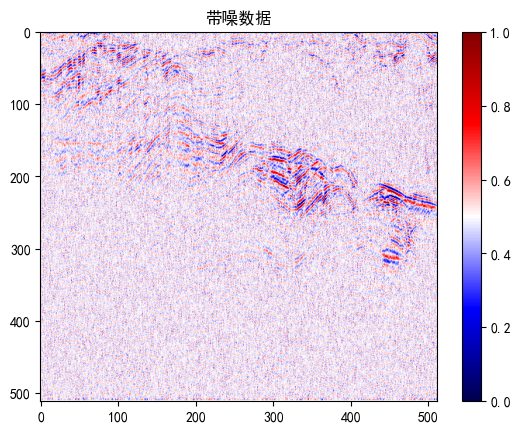

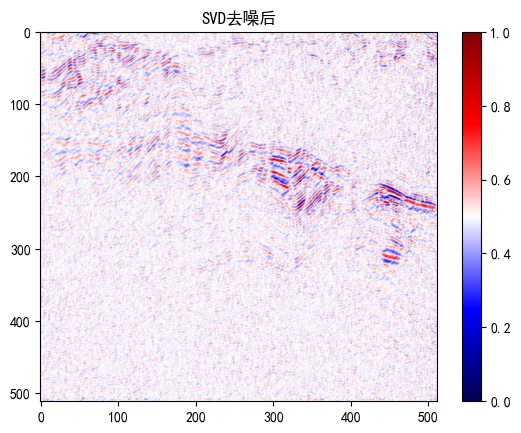

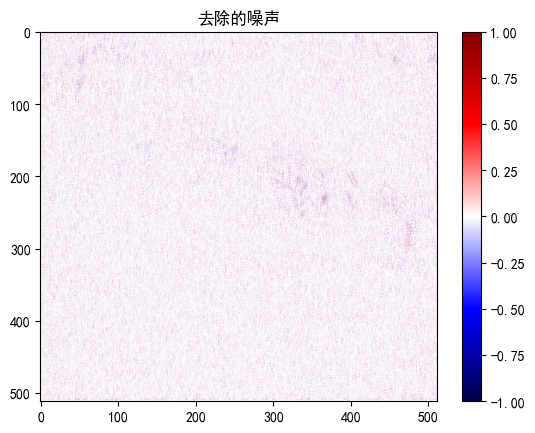

In [2]:
#传统方法去噪  BLACK Bridge
#
if __name__ == '__main__':
    import numpy as np
    from scipy.fft import rfft, irfft
    from scipy.linalg import eigh
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_patch(patch):
        min_val = patch.min()
        max_val = patch.max()
        if max_val - min_val < 1e-6:
            return np.zeros_like(patch)
        return (patch - min_val) / (max_val - min_val)

    def fx_sgd_denoise(data, dx, rank=None):

        # 1. 傅里叶变换到频率域
        freq_data = rfft(data, axis=0)
        nf, nx = freq_data.shape
        denoised_freq = np.zeros_like(freq_data, dtype=complex)
        
        for f_idx in range(nf):
            freq_slice = freq_data[f_idx, :]
            
            # 2. 构建Hankel轨迹矩阵
            L = nx - dx + 1
            H = np.zeros((dx, L), dtype=complex)
            for i in range(dx):
                H[i, :] = freq_slice[i:i+L]
            
            # 3. 计算协方差矩阵 A = H^T H
            A = H.T.conj() @ H  # A维度: L×L
            
            # 4. 构建Hamiltonian矩阵 M = [[A, 0], [0, -A^T]]
            M_upper = np.hstack([A, np.zeros((L, L))])
            M_lower = np.hstack([np.zeros((L, L)), -A.T])
            M = np.vstack([M_upper, M_lower])  # M维度: 2L×2L
            
            # 5. 计算N = M^2
            N = M @ M
            
            # 6. 特征分解
            eigvals, eigvecs = eigh(N)  # eigvecs维度: 2L×2L
            
            # 7. 自适应秩选择
            if rank is None:
                # 简化的自适应秩选择（实际应使用辛几何熵）
                svd_vals = np.sqrt(np.abs(eigvals))
                cumulative = np.cumsum(svd_vals[::-1])
                total = cumulative[-1]
                rank = np.argmax(cumulative > 0.95*total) + 1
            
            Q = eigvecs[:, -rank:]
            
            # 重构公式: \widetilde{H} = H @ (V @ V^H)
            # V是A的特征向量 (来自Q的子矩阵)
            V = Q[:L, :]  # 取前L行 (L×m)
            H_recon = H @ (V @ V.T.conj())  # (dx×L) @ (L×L) = dx×L
            
            # 9. 对角平均还原数据
            denoised_slice = np.zeros(nx, dtype=complex)
            count = np.zeros(nx)
            for i in range(dx):
                for j in range(L):
                    idx = i + j
                    denoised_slice[idx] += H_recon[i, j]
                    count[idx] += 1
            denoised_freq[f_idx, :] = denoised_slice / np.maximum(count, 1)
        
        return irfft(denoised_freq, axis=0, n=data.shape[0])

    # 使用示例
    if __name__ == "__main__":

        data = np.load(r"D:\桌面\随机噪声压制\Black Bridge\data\noised(k=2)(15-55).npy")
        dx = 400 # x方向嵌入维度
        rank = 40 # 固定秩参数
        
        # 执行降噪
        denoised = fx_sgd_denoise(data, dx, rank)
        colors = [(0, 0, 0), (1, 1, 1), (1, 0, 0)]  # 黑 → 白 → 红
        black_white_red = LinearSegmentedColormap.from_list('black_white_red', colors, N=256)

        # np.save(r"D:\桌面\项目\Stratton\方法对比\BLACK_CONVENTIONAL_DENOISED", denoised)
        # np.save(r"D:\桌面\项目\Stratton\方法对比\BLACK_CONVENTIONAL_NOISE", data-denoised)

        # # 绘图对比
        plt.figure()
        # plt.imshow(data, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.imshow(data, "seismic", aspect='auto')
        plt.title('带噪数据')
        plt.clim(0,1)
        plt.colorbar()

        plt.figure()
        plt.imshow(denoised, "seismic", aspect='auto')
        # plt.imshow(denoised, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.title('SVD去噪后')
        plt.clim(0,1)
        plt.colorbar()

        plt.figure()
        # plt.imshow(data-denoised, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.imshow(data-denoised, "seismic", aspect='auto')
        plt.title('去除的噪声')
        plt.clim(-1,1)
        plt.colorbar()
        plt.show()

In [ ]:
#U-Net3+去噪
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    # from U_Net import UNet 
    from UNet_3Plus import UNet_3Plus_DeepSup  
    from matplotlib.colors import LinearSegmentedColormap
    from U_Net_CBAM import UNet
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  
    rcParams['axes.unicode_minus'] = False  

    def normalize_data(data):
        min_val = data.min()
        max_val = data.max()
        return (data - min_val) / (max_val - min_val)

    model = UNet_3Plus_DeepSup(in_channels=1, n_classes=1)
    model_path = r'D:\桌面\项目\Stratton\U_Net3+_718\model_epoch_200.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))

    data = np.load(r"D:\桌面\项目\Stratton\data\Stratton3D_32bit.npy")
    # data = data[50, 6:230, 126:1486]  
    # data = data[50, 6:230, 1126:1494] 
    data = data[200, 72:200, 1050:1418] #论文里的
    # data = data[150, 50:178, 750:1118] 
    data = data.T

    data = normalize_data(data)
    marmousi_clean = data
    marmousi_noisy = data
    marmousi_clean = torch.tensor(marmousi_clean, dtype=torch.float32)
    marmousi_noisy = torch.tensor(marmousi_noisy, dtype=torch.float32)
    input = marmousi_noisy.unsqueeze(0).unsqueeze(0)

    model.eval() 
    with torch.no_grad():
        prediction = model(input)
        prediction, *_ = prediction  
        initial = input.squeeze(0).squeeze(0).numpy()
        pure = marmousi_clean.squeeze(0).numpy()
        result = prediction.squeeze(0).squeeze(0).numpy()
        noise = initial - result

        colors = [(0, 0, 0), (1, 1, 1), (1, 0, 0)]  # 黑 → 白 → 红
        black_white_red = LinearSegmentedColormap.from_list('black_white_red', colors, N=256)

        plt.figure()
        plt.title('含噪数据')
        # plt.imshow(initial, aspect='auto', cmap='seismic')
        plt.imshow(initial, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.clim(0, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        plt.figure()
        plt.title('去噪结果')
        plt.imshow(result, cmap=black_white_red, aspect='auto', interpolation='nearest')
        # plt.imshow(result, aspect='auto', cmap='seismic')
        plt.clim(0, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        plt.figure()
        plt.title('去除的噪声')
        # plt.imshow(res, aspect='auto', cmap='seismic')
        plt.imshow(noise, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.clim(-1, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        # plt.tight_layout()
        # plt.savefig(r"D:\桌面\U_Net3\开源数据集训练CODE\训练日志(15-55hz)\model_725.png", dpi = 2400)
        plt.show()

In [ ]:
# CU-Net去噪
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    # from U_Net import UNet 
    from UNet_3Plus import UNet_3Plus_DeepSup  # 请确保你的模型类是正确导入的
    from matplotlib.colors import LinearSegmentedColormap
    from U_Net_CBAM import UNet
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_data(data):
        min_val = data.min()
        max_val = data.max()
        return (data - min_val) / (max_val - min_val)

    model = UNet()
    model_path = r'D:\桌面\项目\Stratton\CU_Net_717_2\model_epoch_290.pth'
    model.load_state_dict(torch.load(model_path, weights_only=True))

    data = np.load(r"D:\桌面\项目\Stratton\data\Stratton3D_32bit.npy")
    # data = data[50, 6:230, 126:1486]  
    # data = data[50, 6:230, 1126:1494] 
    data = data[200, 72:200, 1050:1418] #论文里的
    # data = data[150, 50:178, 750:1118] 
    data = data.T

    data = normalize_data(data)
    marmousi_clean = data
    marmousi_noisy = data
    marmousi_clean = torch.tensor(marmousi_clean, dtype=torch.float32)
    marmousi_noisy = torch.tensor(marmousi_noisy, dtype=torch.float32)
    input = marmousi_noisy.unsqueeze(0).unsqueeze(0)

    model.eval() 
    with torch.no_grad():
        prediction = model(input)
        prediction, *_ = prediction  
        initial = input.squeeze(0).squeeze(0).numpy()
        pure = marmousi_clean.squeeze(0).numpy()
        result = prediction.squeeze(0).squeeze(0).numpy()
        noise = initial - result

        np.save(r"D:\桌面\项目\Stratton\方法对比\UNET3+_CONVENTIONAL_DENOISED.npy", result)
        np.save(r"D:\桌面\项目\Stratton\方法对比\UNET3+_CONVENTIONAL_NOISE.npy", noise)

        colors = [(0, 0, 0), (1, 1, 1), (1, 0, 0)]  # 黑 → 白 → 红
        black_white_red = LinearSegmentedColormap.from_list('black_white_red', colors, N=256)

        plt.figure()
        plt.title('含噪数据')
        # plt.imshow(initial, aspect='auto', cmap='seismic')
        plt.imshow(initial, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.clim(0, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        plt.figure()
        plt.title('去噪结果')
        plt.imshow(result, cmap=black_white_red, aspect='auto', interpolation='nearest')
        # plt.imshow(result, aspect='auto', cmap='seismic')
        plt.clim(0, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        plt.figure()
        plt.title('去除的噪声')
        # plt.imshow(res, aspect='auto', cmap='seismic')
        plt.imshow(noise, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.clim(-1, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        # plt.tight_layout()
        # plt.savefig(r"D:\桌面\U_Net3\开源数据集训练CODE\训练日志(15-55hz)\model_725.png", dpi = 2400)
        plt.show()

In [ ]:
#U-Net去噪
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    import torch
    # from U_Net import UNet 
    from UNet_3Plus import UNet_3Plus_DeepSup  # 请确保你的模型类是正确导入的
    from matplotlib.colors import LinearSegmentedColormap
    from U_Net_CBAM import UNet
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']  # 或者 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

    def normalize_data(data):
        min_val = data.min()
        max_val = data.max()
        return (data - min_val) / (max_val - min_val)

    model1 = UNet()
    model_path = r'D:\桌面\项目\Stratton\CU_Net_723\model_epoch_50.pth'
    model1.load_state_dict(torch.load(model_path, weights_only=True))

    data = np.load(r"D:\桌面\项目\Stratton\data\Stratton3D_32bit.npy")
    # data = data[50, 6:230, 126:1486]  
    # data = data[50, 6:230, 1126:1494] 
    data = data[200, 72:200, 1050:1418] #论文里的
    # data = data[150, 50:178, 750:1118] 
    data = data.T

    data = normalize_data(data)
    marmousi_clean = data
    marmousi_noisy = data
    marmousi_clean = torch.tensor(marmousi_clean, dtype=torch.float32)
    marmousi_noisy = torch.tensor(marmousi_noisy, dtype=torch.float32)
    input = marmousi_noisy.unsqueeze(0).unsqueeze(0)

    model1.eval() 
    with torch.no_grad():
        prediction = model1(input)
        prediction, *_ = prediction  
        initial = input.squeeze(0).squeeze(0).numpy()
        pure = marmousi_clean.squeeze(0).numpy()
        result = prediction.squeeze(0).squeeze(0).numpy()
        noise = initial - result

        # np.save(r"D:\桌面\项目\Stratton\方法对比\CONVENTIONAL_UNET_STRATTON_DENOISED.npy", result)
        # np.save(r"D:\桌面\项目\Stratton\方法对比\CONVENTIONAL_UNET_STRATTON_NOISE.npy", noise)

        colors = [(0, 0, 0), (1, 1, 1), (1, 0, 0)]  # 黑 → 白 → 红
        black_white_red = LinearSegmentedColormap.from_list('black_white_red', colors, N=256)

        # plt.figure()
        # plt.title('含噪数据')
        # # plt.imshow(initial, aspect='auto', cmap='seismic')
        # plt.imshow(initial, cmap=black_white_red, aspect='auto', interpolation='nearest')
        # plt.clim(0, 1)
        # plt.colorbar(label='Amplitude (VDD)')
        # plt.ylabel('Samples')

        plt.figure()
        plt.title('去噪结果')
        plt.imshow(result, cmap=black_white_red, aspect='auto', interpolation='nearest')
        # plt.imshow(result, aspect='auto', cmap='seismic')
        plt.clim(0, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')

        plt.figure()
        plt.title('去除的噪声')
        # plt.imshow(res, aspect='auto', cmap='seismic')
        plt.imshow(noise, cmap=black_white_red, aspect='auto', interpolation='nearest')
        plt.clim(-1, 1)
        plt.colorbar(label='Amplitude (VDD)')
        plt.ylabel('Samples')
        plt.show()

In [ ]:
#MSSA去噪
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    import warnings
    def fx_mssa_classic(data, flow=5, fhigh=80, dt=0.002, N=1, verb=False):
        if data.ndim != 2:
            raise ValueError("Input data must be 2D array (nt, nx)")
        nt, nx = data.shape
        print(f"Input data shape: {nt} x {nx}")
        # Initialize output
        data_out = np.zeros_like(data)
        # FFT parameters
        nf = 2 ** int(np.ceil(np.log2(nt)))
        # Transform to F-X domain
        data_fx = np.fft.fft(data, nf, axis=0)
        data_fx_out = np.zeros((nf, nx), dtype=complex)
        # Frequency bounds
        ilow = max(1, int(flow * dt * nf) + 1)
        ihigh = min(int(nf/2), int(fhigh * dt * nf) + 1)
        # Hankel matrix parameters
        L = min(int(nx/2), 20)  # Window length, typically nx/2 but limited for efficiency
        K = nx - L + 1          # Number of windows
        print(f"Processing frequencies: {ilow} to {ihigh}")
        print(f"Hankel matrix size: {L} x {K}")
        print(f"Preserving {N} singular values")
        # Main processing loop
        processed_freqs = 0
        for k in range(ilow, ihigh + 1):
            # Extract frequency slice
            freq_slice = data_fx[k, :]
            H = form_hankel_matrix(freq_slice, L)
            try:
                U, s, Vt = np.linalg.svd(H, full_matrices=False)
                H_denoised = U[:, :N] @ np.diag(s[:N]) @ Vt[:N, :]
                data_fx_out[k, :] = reconstruct_from_hankel(H_denoised, nx, L)
                processed_freqs += 1
            except np.linalg.LinAlgError:
                warnings.warn(f"SVD failed at frequency {k}, keeping original")
                data_fx_out[k, :] = data_fx[k, :]
            if verb and k % 20 == 0:
                print(f"Processed frequency {k}/{ihigh} (f={k/(nf*dt):.1f} Hz)")
        print(f"Successfully processed {processed_freqs} frequencies")
        for k in range(int(nf/2) + 1, nf):
            data_fx_out[k, :] = np.conj(data_fx_out[nf - k, :])
        data_out = np.real(np.fft.ifft(data_fx_out, axis=0))
        data_out = data_out[:nt, :]
        return data_out
    
    def form_hankel_matrix(x, L):
        N = len(x)
        K = N - L + 1
        if K <= 0:
            raise ValueError(f"Window length L={L} too large for array length {N}")
        H = np.zeros((L, K), dtype=x.dtype)
        for i in range(L):
            H[i, :] = x[i:i+K]
        return H
    
    def reconstruct_from_hankel(H, N, L):
        K = N - L + 1
        x = np.zeros(N, dtype=H.dtype)
        for n in range(N):
            count = 0
            sum_val = 0
            for i in range(L):
                j = n - i
                if 0 <= j < K:
                    sum_val += H[i, j]
                    count += 1
            if count > 0:
                x[n] = sum_val / count
        return x
    
    def visualize_results(original, denoised, dt=0.002, figsize=(15, 5)):
        noise = original - denoised
        nt, nx = original.shape
        t = np.arange(nt) * dt
        vmax = np.percentile(np.abs(original), 98)
        vmax_noise = np.percentile(np.abs(noise), 98)
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        # Original data
        im1 = axes[0].imshow(original, cmap='seismic', aspect='auto')
        axes[0].set_title('Original Data')
        axes[0].set_xlabel('Trace Number')
        axes[0].set_ylabel('Time (s)')
        plt.colorbar(im1, ax=axes[0], shrink=0.8)
        # Denoised data
        im2 = axes[1].imshow(denoised, cmap='seismic', aspect='auto')
        axes[1].set_title('Denoised Data')
        axes[1].set_xlabel('Trace Number')
        axes[1].set_ylabel('Time (s)')
        plt.colorbar(im2, ax=axes[1], shrink=0.8)
        # Noise
        im3 = axes[2].imshow(noise, cmap='seismic', aspect='auto')
        axes[2].set_title('Removed Noise')
        axes[2].set_xlabel('Trace Number')
        axes[2].set_ylabel('Time (s)')
        plt.colorbar(im3, ax=axes[2], shrink=0.8)
        plt.tight_layout()
        plt.show()

        original_rms = np.sqrt(np.mean(original**2))
        denoised_rms = np.sqrt(np.mean(denoised**2))
        noise_rms = np.sqrt(np.mean(noise**2))
        print(f"\nStatistics:")
        print(f"Original RMS:  {original_rms:.6f}")
        print(f"Denoised RMS:  {denoised_rms:.6f}")
        print(f"Noise RMS:     {noise_rms:.6f}")
        print(f"Signal preservation: {denoised_rms/original_rms*100:.1f}%")
        print(f"Noise removal: {noise_rms/original_rms*100:.1f}%")

    def compare_single_trace(original, denoised, trace_idx=None, dt=0.002):
        nt, nx = original.shape
        if trace_idx is None:
            trace_idx = nx // 2
        t = np.arange(nt) * dt
        noise = original - denoised
        plt.figure(figsize=(12, 8))
 
        plt.subplot(2, 2, 1)
        plt.plot(t, original[:, trace_idx], 'b-', label='Original', linewidth=1)
        plt.plot(t, denoised[:, trace_idx], 'r-', label='Denoised', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.title(f'Trace {trace_idx} - Time Domain')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.subplot(2, 2, 2)
        plt.plot(t, noise[:, trace_idx], 'g-', linewidth=1)
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.title('Removed Noise')
        plt.grid(True, alpha=0.3)
        
        freqs = np.fft.fftfreq(nt, dt)[:nt//2]
        original_fft = np.abs(np.fft.fft(original[:, trace_idx]))[:nt//2]
        denoised_fft = np.abs(np.fft.fft(denoised[:, trace_idx]))[:nt//2]
        noise_fft = np.abs(np.fft.fft(noise[:, trace_idx]))[:nt//2]
        plt.subplot(2, 2, 3)
        plt.semilogy(freqs, original_fft, 'b-', label='Original', linewidth=1.5)
        plt.semilogy(freqs, denoised_fft, 'r-', label='Denoised', linewidth=1.5)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude')
        plt.title('Frequency Domain')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.subplot(2, 2, 4)
        plt.semilogy(freqs, noise_fft, 'g-', linewidth=1.5)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Amplitude')
        plt.title('Noise Spectrum')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def process_seismic_data(filename, flow=5, fhigh=80, dt=0.002, N=1, 
                            visualize=True, save_result=True):
        try:
            data = np.load(filename)
            print(f"Loaded data from: {filename}")
            print(f"Data shape: {data.shape}")
        except FileNotFoundError:
            print(f"Error: File {filename} not found")
            return None, None
        if data.ndim != 2:
            print("Error: Data must be 2D (time, traces)")
            return None, None

        nyquist = 1 / (2 * dt)
        if fhigh >= nyquist:
            print(f"Warning: fhigh ({fhigh} Hz) >= Nyquist ({nyquist:.1f} Hz)")
            fhigh = nyquist * 0.8
            print(f"Adjusted fhigh to {fhigh:.1f} Hz")
        
        print(f"\nProcessing parameters:")
        print(f"Frequency range: {flow} - {fhigh} Hz")
        print(f"Sampling interval: {dt} s")
        print(f"Singular values preserved: {N}")

        print(f"\nStarting F-X MSSA processing...")
        denoised = fx_mssa_classic(data, flow=flow, fhigh=fhigh, dt=dt, N=N, verb=True)
        print("Processing completed!")

        if save_result:
            output_file = filename.replace('.npy', '_denoised.npy')
            np.save(output_file, denoised)
            print(f"Saved denoised data to: {output_file}")
            
            noise_file = filename.replace('.npy', '_noise.npy')
            np.save(noise_file, data - denoised)
            print(f"Saved noise to: {noise_file}")

        if visualize:
            print("\nGenerating visualizations...")
            visualize_results(data, denoised, dt)
            compare_single_trace(data, denoised, dt=dt)
        return data, denoised

    if __name__ == "__main__":
        # Example usage
        filename = r"D:\桌面\项目\U_Net3+ 合成记录测试\开源数据集训练CODE\data\noised(k=3).npy"  # Replace with your file

        original, denoised = process_seismic_data(
            filename, 
            flow=5,          # Hz
            fhigh=80,        # Hz  
            dt=0.004,        # s
            N=3,             # Conservative
            visualize=True,
            save_result=False
        )

Processed D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_CONVENTIONAL_DENOISED.npy: min=-6.551344941536877, max=4.817279021318093
Processed D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_UNET_DENOISED.npy: min=-6.132763862609863, max=4.838476657867432
Processed D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_UNET3+_DENOISED.npy: min=-5.585543155670166, max=5.009729385375977
Processed D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_NOISED.npy: min=-4.93592801416743, max=4.899066992654475


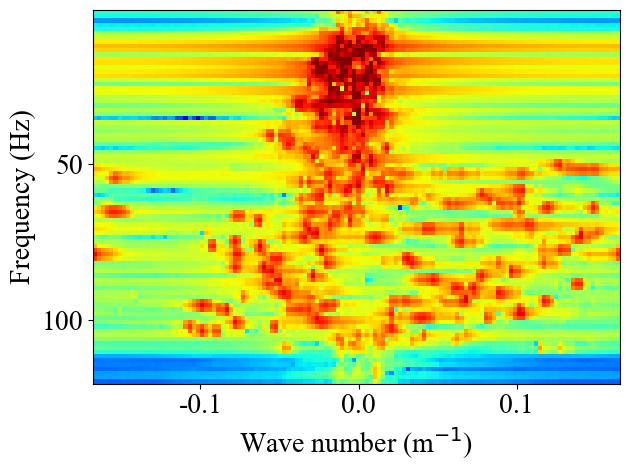

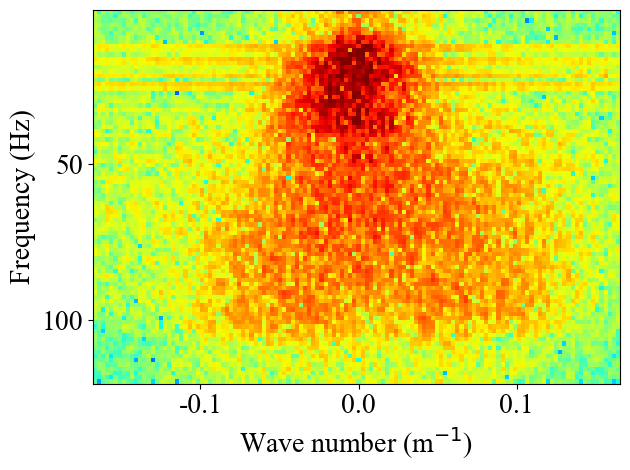

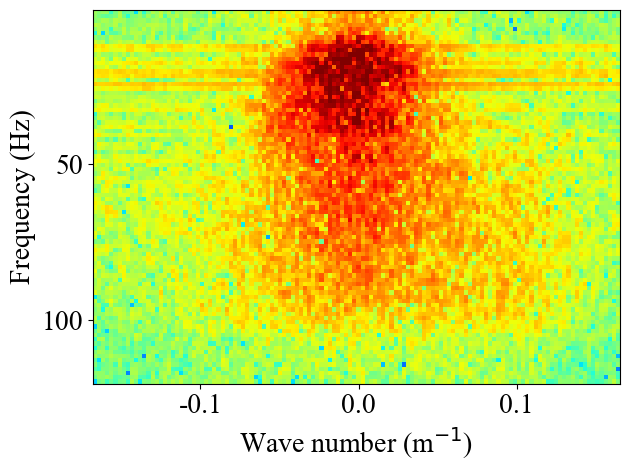

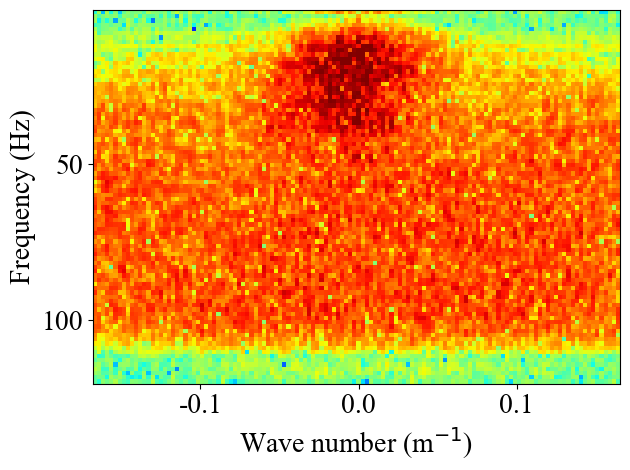

In [66]:
#F-K谱
if __name__ == '__main__':
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.fft import fft2, fftshift, fftfreq
    from matplotlib import rcParams
    import os

    # 中文和负号显示设置
    rcParams['font.sans-serif'] = ['SimHei']  # 或 'Microsoft YaHei'
    rcParams['axes.unicode_minus'] = False

    # === 参数设置 ===
    dt = 0.002  # 时间采样间隔（秒）
    dx = 3        # 道距（米）
    f_max_display = 120  # 最大频率显示范围
    k_max_display = 0.5  # 最大波数显示范围

    # === 你要绘制的文件路径列表 ===
    file_list = [
        r"D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_CONVENTIONAL_DENOISED.npy",
        r"D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_UNET_DENOISED.npy",
        r"D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_UNET3+_DENOISED.npy",
        r"D:\桌面\项目\Stratton\数据汇总\Stratton\STRATTON_NOISED.npy"
        # 如果还有其他文件，继续加
    ]

    # === 第一遍：计算所有谱的最大最小值 ===
    fk_logs = []
    global_min, global_max = np.inf, -np.inf

    for file_path in file_list:
        data = np.load(file_path)
        nt, nx = data.shape

        data = data - np.mean(data, axis=0)
        window = np.hanning(nt)[:, None]
        data *= window

        fk_spectrum = np.abs(fftshift(fft2(data)))**2
        fk_log = np.log10(fk_spectrum + 1e-10)

        fk_logs.append(fk_log)
        global_min = min(global_min, np.min(fk_log))
        global_max = max(global_max, np.max(fk_log))
        print(f"Processed {file_path}: min={np.min(fk_log)}, max={np.max(fk_log)}")

    # === 第二遍：绘图并统一 colorbar ===
    for i, file_path in enumerate(file_list):
        filename = os.path.splitext(os.path.basename(file_path))[0]
        fk_log = fk_logs[i]

        f = fftshift(fftfreq(fk_log.shape[0], dt))  # Hz
        k = fftshift(fftfreq(fk_log.shape[1], dx))  # m^-1
        f_mask = (f > 0) & (f < f_max_display)
        k_mask = np.abs(k) < k_max_display

        plt.figure()
        plt.pcolormesh(k[k_mask], f[f_mask], fk_log[f_mask][:, k_mask],
                    cmap='jet', shading='auto',
                    vmin=global_min, vmax=global_max)
        plt.xlabel("Wave number (m$^{-1}$)", fontsize=20, family='Times New Roman')
        plt.ylabel("Frequency (Hz)", fontsize=20, family='Times New Roman')
        plt.xticks(fontsize=20, fontname='Times New Roman')
        plt.yticks(fontsize=20, fontname='Times New Roman')
        plt.locator_params(axis='x', nbins=4)  # 横轴大约6个刻度
        plt.locator_params(axis='y', nbins=4)  # 纵轴大约8个刻度
        plt.clim(-6, 4)
        # plt.title(f"F-K Spectrum {filename}", fontsize=14)
        # plt.colorbar(label="log10(Amplitude)")
        plt.gca().invert_yaxis()
        plt.tight_layout()

        # np.save(f"D:\桌面\项目\Stratton\数据汇总\Stratton\{filename}_FK.npy", fk_log)

        # # # === 保存图像 ===
        # save_path = rf"D:\桌面\项目\Stratton\图件汇总（刻度线朝内）\Stratton\{filename}_FK.png"
        # plt.savefig(save_path, dpi=600, bbox_inches='tight')

        # === 保存为 PNG + EPS ===
        save_dir = r"D:\桌面\项目\Stratton\矢量图(Times New Roman)\Stratton"
        os.makedirs(save_dir, exist_ok=True)  # 自动创建目录（如不存在）
        save_base = os.path.join(save_dir, f"{filename}_FK")
        plt.savefig(f"{save_base}.png", format='png', dpi=600, bbox_inches='tight')  # 位图
        plt.savefig(f"{save_base}.eps", format='eps', dpi=600, bbox_inches='tight')  # 矢量图

        plt.show()


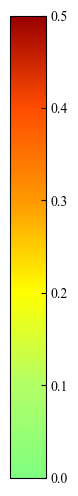

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 设置论文格式字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# 自定义颜色映射
color_list = [
    (0.0, '#7fff7f'),   # 亮绿色
    (0.2, '#b3ff66'),   # 浅绿色
    (0.4, '#ffff00'),   # 黄色
    (0.6, '#ff9900'),   # 橙色
    (0.8, '#ff4d00'),   # 红橙色
    (1.0, '#990000')    # 深红色
]
cust_cmap = LinearSegmentedColormap.from_list('seismic_green', color_list)

# 归一化范围
norm = mcolors.Normalize(vmin=0, vmax=0.5)

# 创建画布
fig, ax = plt.subplots(figsize=(0.6, 6))  # 竖向色条
fig.subplots_adjust(left=0.3)

# 添加竖向 colorbar
cb = colorbar.ColorbarBase(
    ax,
    cmap=cust_cmap,
    norm=norm,
    orientation='vertical',
    ticklocation='right'
)

# 设置刻度
ticks = np.round(np.linspace(0, 0.5, 6), 1)
cb.set_ticks(ticks)
cb.ax.set_yticklabels([f"{t:.1f}" for t in ticks])  # ✅ 修复点

# 样式调整
cb.ax.tick_params(labelsize=10, direction='in')

# 保存图像
plt.savefig(
    r"D:\桌面\项目\Stratton\图件汇总\colorbar\colorbar_SSIM_H.png",
    dpi=600,
    bbox_inches='tight',
    transparent=True
)
plt.show()


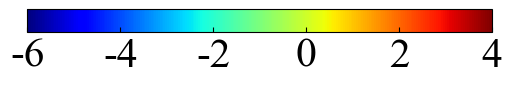

In [80]:
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
import matplotlib.colors as colors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# === 全局参数设置 ===
plt.rcParams['font.family'] = 'Times New Roman'  # 论文常用字体
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

# === 自定义色带 ===
color_list = [
    (0.0, '#7fff7f'),
    (0.2, '#b3ff66'),
    (0.4, '#ffff00'),
    (0.6, '#ff9900'),
    (0.8, '#ff4d00'),
    (1.0, '#990000')
]
cust_cmap = LinearSegmentedColormap.from_list('seismic_green', color_list)

# === 规范化和绘图 ===
vmin= -6
vmax= 4
norm = colors.Normalize(vmin, vmax)
fig, ax = plt.subplots(figsize=(6, 0.6))
fig.subplots_adjust(bottom=0.5)

cb = colorbar.ColorbarBase(
    ax,
    cmap="jet",
    norm=norm,
    orientation='horizontal',
    ticklocation='bottom'
)

ticks = np.linspace(vmin, vmax, 6)
cb.set_ticks(ticks)
cb.ax.set_xticklabels([f"{t:.0f}" for t in ticks])
cb.ax.tick_params(labelsize=30, direction='in')

# === 保存为 .eps 和 .png ===
save_base = r"D:\桌面\项目\Stratton\矢量图\colorbar\colorbar_FK"
plt.savefig(f"{save_base}.eps", format='eps', dpi = 600, bbox_inches='tight', transparent=True)
plt.savefig(f"{save_base}.png", format='png', dpi = 600, bbox_inches='tight', transparent=True)
plt.show()
